In [23]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit', includeTestInTrain=False)

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [24]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [25]:
# Check label values to understand the data
import torch
all_labels_check = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    all_labels_check.extend(labels.numpy())

print("Unique labels in training set:", set(all_labels_check))
print("Min label:", min(all_labels_check))
print("Max label:", max(all_labels_check))
print("Label counts:", {label: all_labels_check.count(label) for label in set(all_labels_check)})


Unique labels in training set: {np.int64(0), np.int64(1), np.int64(2)}
Min label: 0
Max label: 2
Label counts: {np.int64(0): 467, np.int64(1): 82, np.int64(2): 46}


In [26]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [27]:
# Reload the modules to get the latest changes
import importlib
import GradientGang.Pipeline.Architectures.LightningAutoencoder
import GradientGang.Pipeline.Architectures.Decoder
import GradientGang.Pipeline.Architectures.Direct
importlib.reload(GradientGang.Pipeline.Architectures.Decoder)
importlib.reload(GradientGang.Pipeline.Architectures.LightningAutoencoder)
importlib.reload(GradientGang.Pipeline.Architectures.Direct)
from GradientGang.Pipeline.Architectures.Direct import Direct

print("✓ Modules reloaded successfully")


✓ Modules reloaded successfully


In [28]:
# Create an optimized direct architecture configuration
# Best Direct architecture: Deep Bidirectional GRU -> Dropout -> FeedForward for classification
architectureDirect = {
    
    "LearningRate": 0.0005,
    "Patience": 10,
    "RegularizationWeight": 0.05,
    
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "GRU",
                "params": {
                    "input_size": 34,
                    "hidden_size": 256,  # Increased hidden size for better capacity
                    "num_layers": 3,     # Deeper network for complex patterns
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.3,      # Increased dropout for regularization
                    "bidirectional": True  # Output will be hidden_size * 2 = 512
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 512,  # 256 * 2 because bidirectional=True
                    "out_features": 256,
                    "bias": True,
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,
                    "out_features": 128,  # Compressed representation
                    "bias": True,
                }
            }
        ]
    },
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,  # 128 (encoder) + 1 (global feature)
                    "out_features": 128,
                    "bias": True,
                }
            },
            {
                "name": "Dropout",
                "params": {
                    "p": 0.4  # Dropout for regularization
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,
                    "out_features": 64,
                    "bias": True,
                }
            },
            {
                "name": "Dropout",
                "params": {
                    "p": 0.3  # Additional dropout layer
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 32,
                    "bias": True,
                }
            }
        ]
    },
    "OutputDim": 3  # Number of classes
}

# Create optimized direct model with the configuration
autoencoder_fixed = Direct(architectureDirect)
print("✓ Optimized Direct architecture created successfully")


✓ Optimized Direct architecture created successfully


In [29]:
# Test the direct architecture to verify it works correctly
import torch
with torch.no_grad():
    test_batch = next(iter(trainLoader))
    (test_time_series, test_global_features), test_labels = test_batch
    print("✓ Input time series shape:", test_time_series.shape)
    print("✓ Input global features shape:", test_global_features.shape)
    print("✓ Input labels shape:", test_labels.shape)
    
    # Direct architecture only returns predictions (no decoder outputs)
    predictions = autoencoder_fixed((test_time_series, test_global_features))
    
    print("\n✓ Output predictions shape:", predictions.shape)
    print("✓ Expected output shape: (batch_size, num_classes) = ({}, 3)".format(test_time_series.shape[0]))
    
    print("\n" + "="*50)
    print("ARCHITECTURE VERIFICATION:")
    print("="*50)
    print(f"Predictions shape: {predictions.shape}")
    print(f"Expected: ({test_time_series.shape[0]}, 3)")
    print(f"Match? {'✅ YES' if predictions.shape == (test_time_series.shape[0], 3) else '❌ NO'}")
    
    # Test prediction output
    print(f"\nPredicted classes: {predictions.argmax(dim=1)[:10]}")
    print(f"True labels: {test_labels[:10]}")


✓ Input time series shape: torch.Size([32, 34, 160])
✓ Input global features shape: torch.Size([32, 1])
✓ Input labels shape: torch.Size([32])

✓ Output predictions shape: torch.Size([32, 3])
✓ Expected output shape: (batch_size, num_classes) = (32, 3)

ARCHITECTURE VERIFICATION:
Predictions shape: torch.Size([32, 3])
Expected: (32, 3)
Match? ✅ YES

Predicted classes: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
True labels: tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

✓ Output predictions shape: torch.Size([32, 3])
✓ Expected output shape: (batch_size, num_classes) = (32, 3)

ARCHITECTURE VERIFICATION:
Predictions shape: torch.Size([32, 3])
Expected: (32, 3)
Match? ✅ YES

Predicted classes: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
True labels: tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])


In [30]:
# Train the direct architecture with optimized settings
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping to prevent overfitting - monitor val_F1 instead of val_loss
early_stop_callback = EarlyStopping(
    monitor='val_F1',
    patience=100,
    mode='max',  # max because we want to maximize F1 score
    verbose=True
)

# Save best model checkpoint
checkpoint_callback = ModelCheckpoint(
    monitor='val_F1',
    mode='max',
    save_top_k=2,
    filename='direct-best-{epoch:02d}-{val_F1:.3f}',
    verbose=True
)

# Create trainer with callbacks
trainer_direct = Trainer(
    max_epochs=500,
    enable_progress_bar=True,
    log_every_n_steps=20,
    callbacks=[early_stop_callback, checkpoint_callback],
    gradient_clip_val=1.0,  # Prevent exploding gradients
)

print("Starting direct architecture training...")
trainer_direct.fit(autoencoder_fixed, trainLoader, valLoader)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 3.0 M  | train
1 | globalff_encoder | FeedForward       | 2      | train
2 | feedforward      | FeedForward       | 27.0 K | train
3 | val_f1           | MulticlassF1Score | 0      | train
---------------------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.021    Total estimated model params size (MB)
23        Modules in train mode
0         Modules in eval mode
HPU available: False, using: 0 HPUs

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 3.0 M  | train
1 | globalff_encode

Starting direct architecture training...
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (19) is smaller than the logging interval Trainer(log_every_n_steps=20). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 19/19 [00:17<00:00,  1.10it/s, v_num=4, val_F1=0.741]

...

Epoch 99, global step 1900: 'val_F1' was not in top 2


Epoch 100:  47%|████▋     | 9/19 [00:06<00:06,  1.43it/s, v_num=4, val_F1=0.742]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [31]:
# Compute F1 score on val set using the Direct architecture
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        preds = autoencoder_fixed(x)  # Direct returns predictions directly (not a tuple)
    all_preds.extend(preds.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels)

#print(all_preds)
#print(all_labels)

f1 = F1Score(task="multiclass", num_classes=3)
f1 = f1(torch.tensor(all_preds), torch.tensor(all_labels))
print("Validation F1 Score:", f1)


Validation F1 Score: tensor(0.7424)


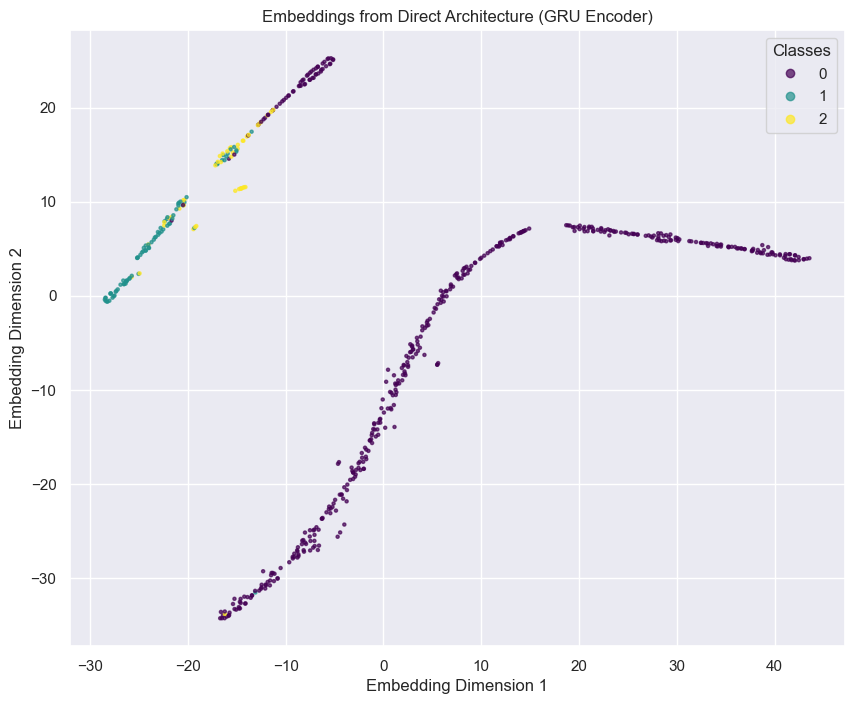

In [32]:
# Plot embeddings using the Direct architecture
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Direct architecture: encode time series through the encoder
        embedding = autoencoder_fixed.encoder(time_series)
    embeddings.append(embedding.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Direct Architecture (GRU Encoder)')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()


In [ ]:
# Reload SubmissionGenerator to get the latest changes
import importlib
import GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator
importlib.reload(GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator)
from GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator import SubmissionGenerator

submission_generator = SubmissionGenerator(
    model=autoencoder_fixed,
    dataloader=testLoader,
    label_mapping={0: 'no_pain', 1: 'low_pain', 2: 'high_pain'},
)

predictions = submission_generator.generate_predictions()
print("Sample Predictions:", predictions[:10])

Sample Predictions: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])


In [ ]:
from datetime import datetime
path = "../Submissions/submission_direct_" + datetime.now().strftime("%H-%M") + ".csv"
path


'../Submissions/submission_direct_17-49.csv'

In [ ]:
submission_generator.generate_submission(
    output_path=path
)

,sample_index,label
0,000,no_pain
1,001,no_pain
2,002,no_pain
3,003,no_pain
4,004,no_pain
...,...,...
1319,1319,no_pain
1320,1320,no_pain
1321,1321,no_pain
1322,1322,no_pain
